Mounted at /content/drive


/tmp/ipython-input-3360308306.py:18: DtypeWarning: Columns (0,1,2,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,26


Data shape after cleaning: (3205, 89)



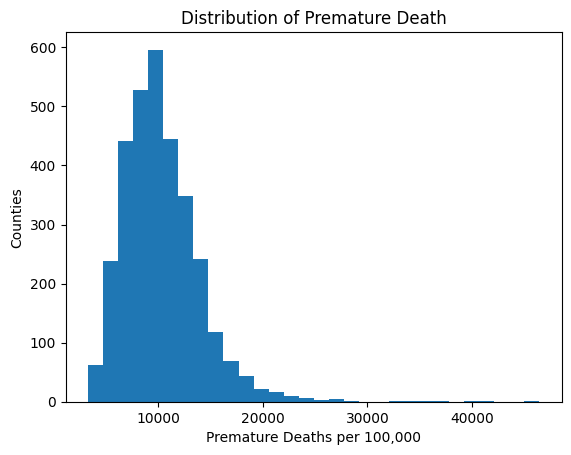


===================== LINEAR REGRESSION (SUPERVISED)  =====================================

(3205, 24) (3205,)
Slope (coefficient): -455.15
Intercept: -3603.21

RMSE: 4488986.524101805
R²: 0.7169700994454096


Top 5 Most Important Features (Linear Regression):
Negative coefficient: decreases death
Positive coefficient: increases death 

                              Feature    Coefficient       AbsCoeff
5   Primary Care Physicians raw value -404755.093792  404755.093792
8                  Dentists raw value  302749.487280  302749.487280
19      Children in Poverty raw value   18012.448781   18012.448781
7   Mental Health Providers raw value  -13407.437893   13407.437893
18             Unemployment raw value   -7315.831554    7315.831554

===================== DECISION TREE (SUPERVISED)  ============================================

Decision Tree Results:
RMSE: 6464801.427586021
MAE: 1488.2711973586024
R²: 0.5923952777913597 


Top 5 Most Important Features (Decision Tree):
          

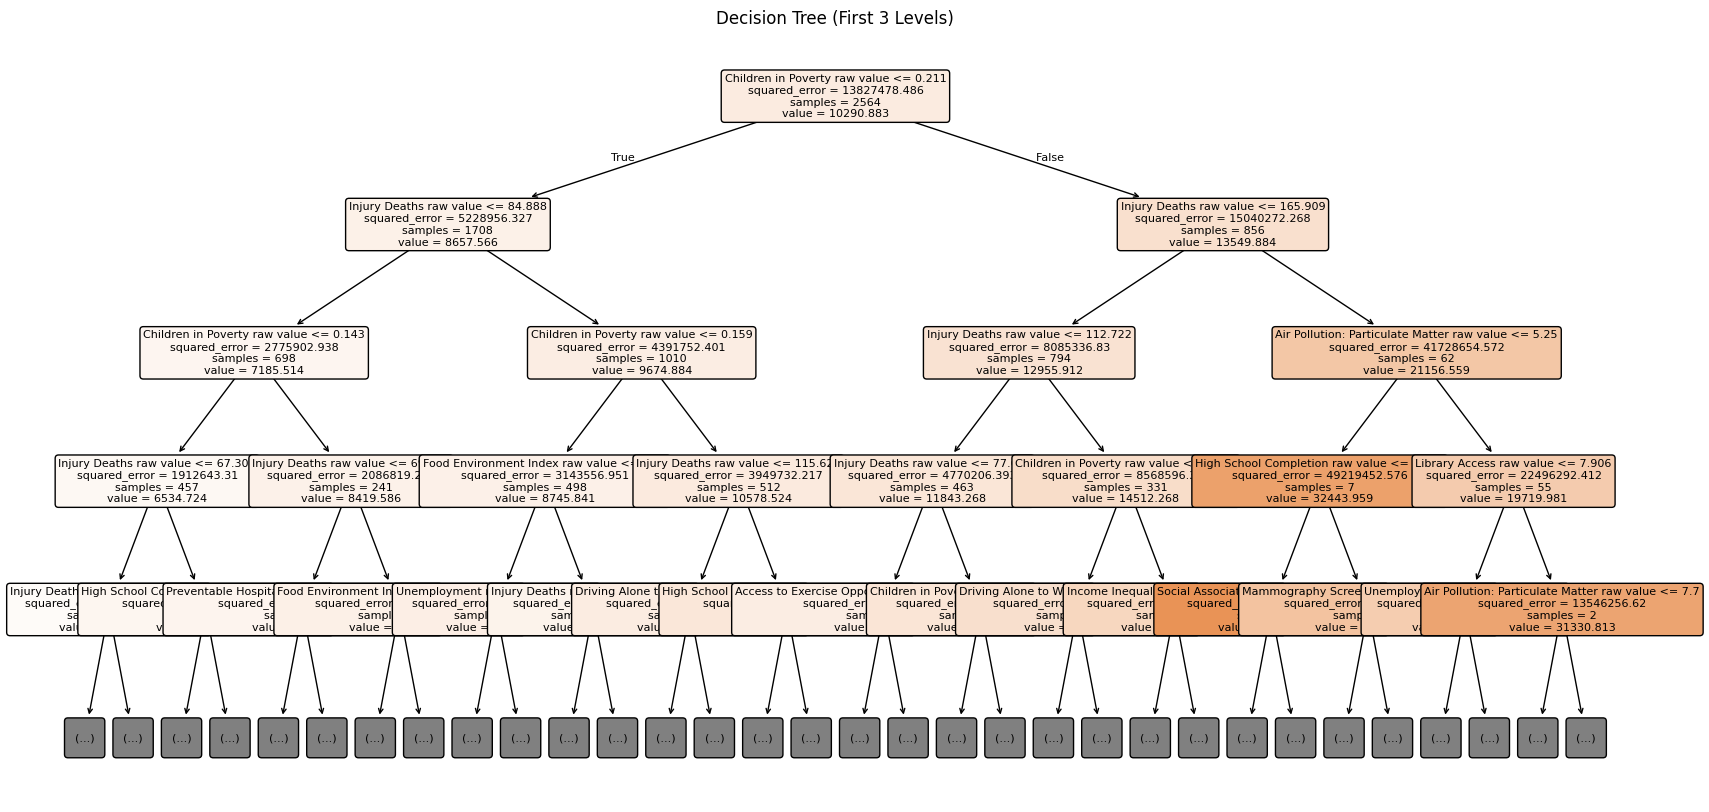

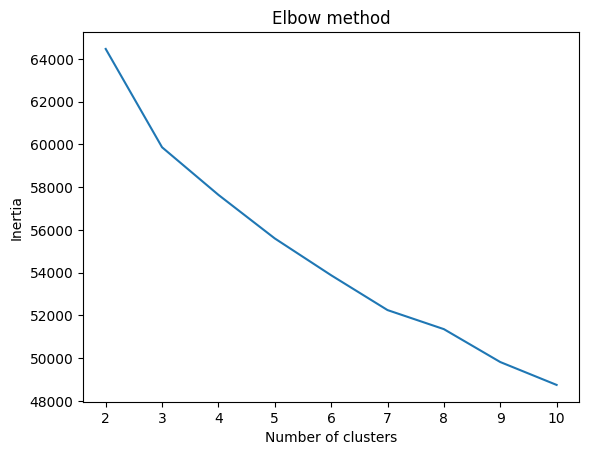

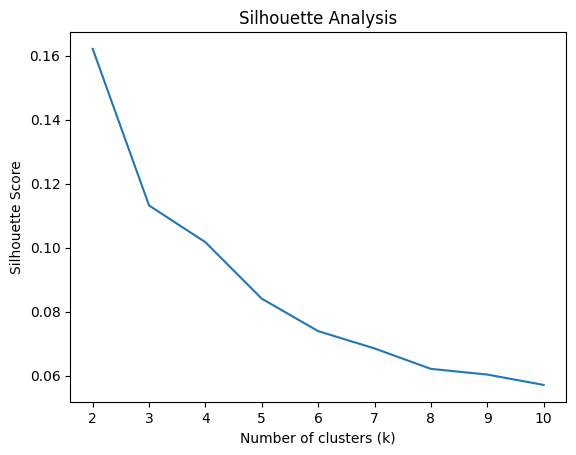


 Because of the way the elbow plot slopes down and doesn't really flatten out, as well as the fact that silhouette score peaks at 2...
I believe the best number of clusters to segment this data into is 2.


In [41]:
#   Brendan R.
#   95-891 Introduction to AI
#   Dr. David Steier
#   HW#1 - Classification and Clustering

import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path = "/content/drive/MyDrive/ExampleDatasets/analytic_data2025_v2.csv"

#   --------------------------------
#   THE DATASET MUST BE IN THE ExampleDatasets FOLDER OF YOUR GOOGLE DRIVE.
#   SEE BELOW IMAGE!
#   --------------------------------

# Load the CSV file
old_df = pd.read_csv(path)

# ==========================    Feature Selection and Data Cleanse ====================

pattern = re.compile(r'v.*_raw')                                                    # Begin by searching for the v***_rawvalue columns in the data

matching_columns = []                                                               # Create an empty dataframe
for col in old_df.columns:
    # Check if any value in the column matches the pattern for rawvalues
    if old_df[col].astype(str).str.match(pattern).any():                            # I created an algorithm for this string match comparison. GenAI helped refine it.   if pattern.search(col):
        matching_columns.append(col)


# Extract matching columns                                                          # Create a separate dataframe of only rawvalues.
df = old_df[matching_columns]

# Convert all selected columns to numeric                                           # Start data cleansing of missing fields and strings.
df = df.apply(pd.to_numeric, errors='coerce')                                       # According to pandas documentation: If ‘coerce’, then invalid parsing will be set as NaN.
                                                                                    # So values that can be changed to numerals will be. If they cannot, they will be set as NaN for handling on the next line.
# Drop problematic columns that contain NaN
df = df.dropna(axis=1, how='all')

# Median imputation                                                                 # For rows that still contain NaN values, perform median imputation to fill these in.
imp_df = df.fillna(df.median())

# Drop any remaining rows with NaN (should be very few after all above adjustments)
imp_df.dropna(inplace=True)

print(f"\nData shape after cleaning: {imp_df.shape}\n")                             # Verify no errors and that data still exists. In my testing, only 1 column of rawdata was eliminated. 90 --> 89.


# Define 'Community Conditions' as features (predictors).
community_features = ['Access to Exercise Opportunities raw value', 'Flu Vaccinations raw value', 'Food Environment Index raw value',
                       'Preventable Hospital Stays raw value', 'Uninsured raw value', 'Primary Care Physicians raw value',
                       'Mammography Screening raw value', 'Mental Health Providers raw value', 'Dentists raw value',
                       'Air Pollution: Particulate Matter raw value', 'Drinking Water Violations raw value', 'Broadband Access raw value',
                       'Library Access raw value', 'Severe Housing Problems raw value', 'Driving Alone to Work raw value',
                       'Long Commute - Driving Alone raw value', 'High School Completion raw value', 'Some College raw value',
                       'Unemployment raw value', 'Children in Poverty raw value', 'Income Inequality raw value',
                       'Child Care Cost Burden raw value', 'Injury Deaths raw value', 'Social Associations raw value']

# Visualize target data.
plt.hist(imp_df['Premature Death raw value'], bins=30)
plt.title('Distribution of Premature Death')
plt.xlabel('Premature Deaths per 100,000')
plt.ylabel('Counties')
plt.show()




print("\n===================== LINEAR REGRESSION (SUPERVISED)  =====================================\n")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score, r2_score, mean_absolute_error

X = imp_df[community_features].copy()                                               # Create a dataframe consisting of only rawvalues of the CommunityConditions.
y = imp_df['Premature Death raw value'].copy()                                      # Create a dataframe consisting of only the Premature Death outcome (target) variable.

print(X.shape, y.shape)

# Split the data into training and test sets. 80/20 split. I've seen this randomness variable used frequently.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model=LinearRegression()                                                            # Create a Linear Regression model instance
model.fit(X_train, y_train)                                                         # Train the model using the independent (X) and dependent (y) variables

slope = model.coef_[0]                                                              # The coefficient (slope) of the regression line
intercept = model.intercept_                                                        # The intercept of the regression line
print(f"Slope (coefficient): {slope:.2f}")
print(f"Intercept: {intercept:.2f}\n")

y_pred = model.predict(X_test)                                                      # Use the model of X test data to predict target variable y.

rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")                                                              # Summary Statistics
print(f"R²: {r2}\n")

print("\nTop 5 Most Important Features (Linear Regression):")
print("Negative coefficient: decreases death")
print("Positive coefficient: increases death \n")

# Create a dataframe of the coefficient magnitude to show the greatest relationship to Premature Death rawvalue
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})          # ChatGPT helped debug this line. I originally had ":model.coef_df". Needed to omit the df."

coef_df['AbsCoeff'] = coef_df['Coefficient'].abs()                                  # Take absolute value to get positive and negative influence.

print(coef_df.sort_values('AbsCoeff', ascending=False).head(5))



print("\n===================== DECISION TREE (SUPERVISED)  ============================================\n")

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

# Create and train the Decision Tree Regressor                                      # From Session 3 slides.
dt_regressor = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_regressor.fit(X_train, y_train)

# Make predictions. From Session 3 slides.
y_pred_dt = dt_regressor.predict(X_test)

rmse_dt = mean_squared_error(y_test, y_pred_dt)                                     # Summary Statistics
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Results:")
print(f"RMSE: {rmse_dt}")
print(f"MAE: {mae_dt}")
print(f"R²: {r2_dt} \n")


print("\nTop 5 Most Important Features (Decision Tree):")
feature_importance_df = pd.DataFrame({'Feature': X.columns,'Importance': dt_regressor.feature_importances_})    # Didn't need AI assistance here after the above^
print(feature_importance_df.sort_values('Importance', ascending=False).head(5))

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(                                                                          # Session 3 slides plus some tweaks.
    dt_regressor,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4
)
plt.title("Decision Tree (First 3 Levels)")
plt.show()



#   ====================    CLUSTERING (UNSUPERVISED)   ====================================

from sklearn.preprocessing import StandardScaler                                    # I struggled a bit on the clustering and left it for last, hoping to get TA assistance on Tuesday.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = imp_df[community_features].copy()                                        # Create a new dataframe with community features.

inertias = []
silhouette_scores = []                                                              # Create empty array for intertias and silhouette scores

scaler = StandardScaler()                                                           # When I ran this cluster model the first few times, I could not get a reliable output.
scaled_features = scaler.fit_transform(features)                                    # GenAI helped me determine this was because I was not scaling the data. These are those
                                                                                    # lines to scale the data, however I've left my code with "unscaled features" below.

for i in range(2, 11):                                                              # Run appropriate amount for k-means elbow method.
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(scaled_features)                                    # Session 4 slides
    #labels = kmeans.fit_predict(features)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, labels))
    #silhouette_scores.append(silhouette_score(features, labels))

# Elbow method plot
plt.plot(range(2, 11), inertias)
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


# Silhouette scores
plt.plot(range(2,11), silhouette_scores)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

print("\n Because of the way the elbow plot slopes down and doesn't really flatten out, as well as the fact that silhouette score peaks at 2...")
print("I believe the best number of clusters to segment this data into is 2.")

k_final = 2

# Judging by the data collected and analyzed above, in the short term, Allegheny County can reduce premature death by increasing the number of primary care physicians serving it's citizens. Because Allegheny is mostly urban area, the number of physicians should be scaled to match the number of people within it's borders, especially in underserved areas. Also, PCP's should focus on early detection of chronic conditions. My linear regression model seemed to have a grudge against dentist and believes the number of dentists negatively impacts the premature death in US counties. So over the long term, Allegheny county could reallocate healthcare resources away from specialties like dentists & orthodontist, toward more primary care like mentioned above.

Sources:


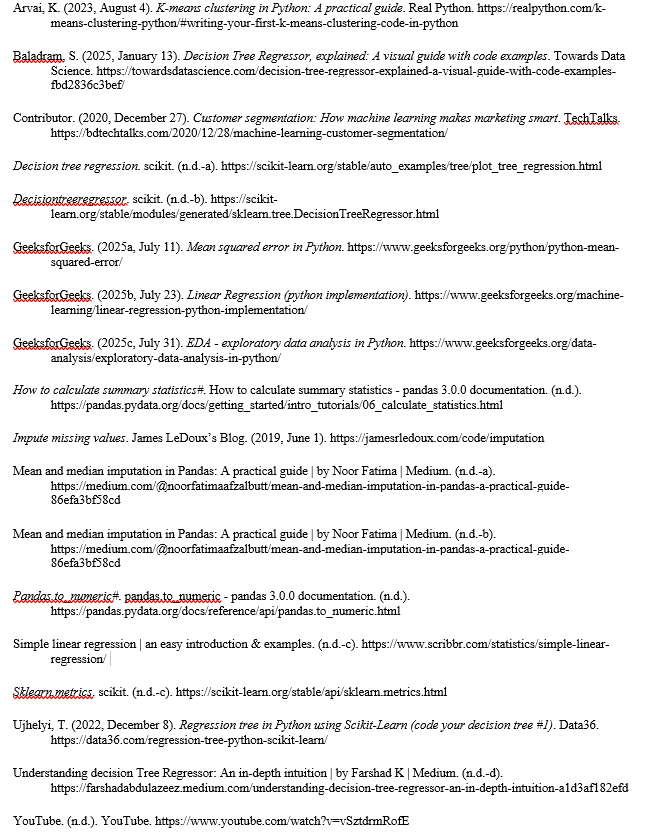